# NYC Energy Star Score — регрессия / regression

**RU.** Учебный проект: предсказание рейтинга энергоэффективности зданий Нью-Йорка (`ENERGY STAR Score`) по данным публичного отчёта *Energy and Water Data Disclosure for Local Law 84 (2016)*. В работе выполнены очистка сырых данных, обработка пропусков и выбросов, отбор признаков несколькими методами, построение препроцессинг-пайплайна и обучение двух линейных моделей — `LinearRegression` и `LinearSVR`.

**EN.** A study project that predicts the energy-efficiency rating of New York City buildings (`ENERGY STAR Score`) from the public *Energy and Water Data Disclosure for Local Law 84 (2016)* dataset. The workflow covers raw-data cleaning, missing-value and outlier handling, multi-method feature selection, a preprocessing pipeline, and the training of two linear models — `LinearRegression` and `LinearSVR`.

**Dataset source / источник данных:** <https://www1.nyc.gov/html/gbee/html/plan/ll84_scores.shtml>

---

### Задачи / Tasks

- **RU.** Построить регрессионные модели `LinearRegression` и `LinearSVR`; применить нормализацию признаков; использовать несколько методов отбора признаков; ответить на вопрос — какие 5 признаков сильнее всего влияют на `ENERGY STAR Score`.
- **EN.** Train `LinearRegression` and `LinearSVR` regressors; apply feature scaling; use several feature-selection techniques; identify the top-5 features that most strongly influence the `ENERGY STAR Score`.

## 1. Импорты и настройки / Imports and setup

**RU.** Единый блок импортов для всего ноутбука.

**EN.** A single imports block used throughout the notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

%matplotlib inline

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)

## 2. Загрузка данных / Data loading

**RU.** Скачиваем CSV-файл с Google Drive (экспорт публичной Google-таблицы) и сохраняем локально. Загрузка обёрнута в функцию — так ноутбук легко перезапустить на чистой машине.

**EN.** Download the CSV from Google Drive (public spreadsheet export) and save it locally. The download is wrapped in a helper function so the notebook is easy to rerun on a fresh machine.

In [ ]:
DATA_URL = (
    "https://docs.google.com/spreadsheets/d/"
    "1xJ8_0TdpsruFsmERCC1EcbQnC227Z8unkOSrhjRh1mA/export?format=csv"
)
DATA_FILE = (
    "Energy_and_Water_Data_Disclosure_for_Local_Law_84_"
    "2017__Data_for_Calendar_Year_2016_.csv"
)


def download_dataset(url: str, file_name: str) -> None:
    """Скачать датасет по ссылке и сохранить в file_name, если он отсутствует.

    Download the dataset from ``url`` and save it to ``file_name``
    if it is not already present locally.
    """
    from os.path import exists

    if exists(file_name):
        print(f"{file_name} уже загружен / already downloaded")
        return

    response = requests.get(url, timeout=60)
    response.raise_for_status()
    with open(file_name, "wb") as f:
        f.write(response.content)
    print(f"Файл сохранён / file saved: {file_name}")


download_dataset(DATA_URL, DATA_FILE)

In [ ]:
data = pd.read_csv(DATA_FILE)
data.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,...,Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,Not Available,...,619.4,05/01/2017 17:32:03,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,Not Available,...,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,177 Fort Washington Ave,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840746,-73.942854,12.0,10.0,255.0,Washington Heights South
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.841559,-73.942528,12.0,10.0,255.0,Washington Heights South


## 3. Первичный осмотр данных / Initial inspection

**RU.** Посмотрим на типы колонок, количество заполненных значений и базовую статистику. Это поможет понять, какие колонки нужно привести к числовому типу и сколько пропусков предстоит обработать.

**EN.** Inspect column dtypes, non-null counts, and basic statistics. This tells us which columns need to be cast to numeric and how many missing values we have to deal with.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 60 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   Property Name                                               11746 non-null  object 
 3   Parent Property Id                                          11746 non-null  object 
 4   Parent Property Name                                        11746 non-null  object 
 5   BBL - 10 digits                                             11735 non-null  object 
 6   NYC Borough, Block and Lot (BBL) self-reported              11746 non-null  object 
 7   NYC Building Identification Number (BIN)                    11746 non-null  object 
 

In [ ]:
data.describe()

,Order,Property Id,DOF Gross Floor Area,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,ENERGY STAR Score,...,Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Latitude,Longitude,Community Board,Council District,Census Tract
count,11746.000000,1.174600e+04,1.162800e+04,1.174400e+04,3741.000000,1484.000000,11746.000000,11746.000000,11746.000000,9642.000000,...,1.168100e+04,1.174600e+04,7.762000e+03,7762.000000,11583.000000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000
mean,7185.759578,3.642958e+06,1.732695e+05,1.605524e+05,22778.682010,12016.825270,1948.738379,1.289971,98.762557,59.854594,...,2.076339e+03,1.673739e+05,1.591798e+04,136.172432,385.908029,40.754379,-73.957057,7.140673,15.771275,4977.596647
std,4323.859984,1.049070e+06,3.367055e+05,3.095746e+05,55094.441422,27959.755486,30.576386,4.017484,7.501603,29.993586,...,5.931295e+04,3.189238e+05,1.529524e+05,1730.726938,9312.736225,0.080120,0.046337,3.954129,15.674375,13520.422990
min,1.000000,7.365000e+03,5.002800e+04,5.400000e+01,0.000000,0.000000,1600.000000,0.000000,0.000000,1.000000,...,-2.313430e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,40.516065,-74.243582,1.000000,1.000000,1.000000
25%,3428.250000,2.747222e+06,6.524000e+04,6.520100e+04,4000.000000,1720.750000,1927.000000,1.000000,100.000000,37.000000,...,9.480000e+01,6.699400e+04,2.595400e+03,27.150000,99.400000,40.707226,-73.984662,4.000000,4.000000,100.000000
50%,6986.500000,3.236404e+06,9.313850e+04,9.132400e+04,8654.000000,5000.000000,1941.000000,1.000000,100.000000,65.000000,...,1.718000e+02,9.408000e+04,4.692500e+03,45.095000,124.900000,40.759130,-73.962810,7.000000,9.000000,201.000000
75%,11054.500000,4.409092e+06,1.596140e+05,1.532550e+05,20000.000000,12000.000000,1966.000000,1.000000,100.000000,85.000000,...,4.249000e+02,1.584140e+05,8.031875e+03,70.805000,162.750000,40.817623,-73.932443,9.000000,33.000000,531.500000
max,14993.000000,5.991312e+06,1.354011e+07,1.421712e+07,962428.000000,591640.000000,2019.000000,161.000000,100.000000,100.000000,...,4.764375e+06,1.421712e+07,6.594604e+06,96305.690000,912801.100000,40.912869,-73.715543,56.000000,51.000000,155101.000000


## 4. Конвертация типов / Type conversion

**RU.** Многие числовые признаки сохранены как строки со значением `"Not Available"`. Заменяем эти маркеры на `NaN` и приводим колонки с физическими единицами измерения к `float`.

**EN.** Several numeric features are stored as strings that contain the marker `"Not Available"`. We replace the marker with `NaN` and cast every column that carries a physical unit to `float`.

In [ ]:
NUMERIC_UNIT_MARKERS = ("ft²", "kBtu", "Metric Tons CO2e", "kWh", "therms", "gal", "Score")


def coerce_numeric_columns(df: pd.DataFrame, markers=NUMERIC_UNIT_MARKERS) -> pd.DataFrame:
    """Заменить 'Not Available' на NaN и привести «числовые» колонки к float.

    Replace ``'Not Available'`` with ``NaN`` and cast every column whose
    name contains a physical-unit marker to ``float``.
    """
    df = df.replace({"Not Available": np.nan})
    for col in df.columns:
        if any(marker in col for marker in markers):
            df[col] = df[col].astype(float)
    return df


data = coerce_numeric_columns(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 60 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   Property Name                                               11746 non-null  object 
 3   Parent Property Id                                          11746 non-null  object 
 4   Parent Property Name                                        11746 non-null  object 
 5   BBL - 10 digits                                             11735 non-null  object 
 6   NYC Borough, Block and Lot (BBL) self-reported              11735 non-null  object 
 7   NYC Building Identification Number (BIN)                    11584 non-null  object 
 

## 5. Анализ пропусков / Missing values

**RU.** Считаем абсолютное количество и долю пропусков по каждой колонке, чтобы понять, где вообще нечего восстанавливать.

**EN.** Count absolute and relative missing values per column to see which features are too sparse to be useful.

In [ ]:
def missing_values_table(df: pd.DataFrame) -> pd.DataFrame:
    """Вернуть таблицу пропусков: количество и процент от общего числа строк.

    Return a table of missing values with counts and percentages, sorted
    by percentage descending. Columns without missing values are dropped.
    """
    missing_count = df.isnull().sum()
    missing_pct = 100 * missing_count / len(df)

    table = (
        pd.concat([missing_count, missing_pct], axis=1)
        .rename(columns={0: "Missing Values", 1: "% of Total Values"})
    )
    table = (
        table[table["% of Total Values"] != 0]
        .sort_values("% of Total Values", ascending=False)
        .round(1)
    )

    print(
        f"Dataframe has {df.shape[1]} columns; "
        f"{table.shape[0]} of them contain missing values."
    )
    return table


missing_values_table(data)

Your selected dataframe has 60 columns.
There are 46 columns that have missing values.


,Missing Values,% of Total Values
Fuel Oil #1 Use (kBtu),11737,99.9
Diesel #2 Use (kBtu),11730,99.9
Address 2,11539,98.2
Fuel Oil #5 & 6 Use (kBtu),11152,94.9
District Steam Use (kBtu),10810,92.0
Fuel Oil #4 Use (kBtu),10425,88.8
3rd Largest Property Use Type - Gross Floor Area (ft²),10262,87.4
3rd Largest Property Use Type,10262,87.4
Fuel Oil #2 Use (kBtu),9165,78.0
2nd Largest Property Use Type,8005,68.2


## 6. Удаление признаков с >50% пропусков / Drop columns with >50% missing

**RU.** Колонки, где пропущена больше половины значений, заполнять бессмысленно — удаляем их целиком.

**EN.** Columns missing more than half their values cannot be imputed meaningfully, so we drop them entirely.

In [ ]:
MISSING_THRESHOLD_PCT = 50

missing_df = missing_values_table(data)
high_missing = list(missing_df[missing_df["% of Total Values"] > MISSING_THRESHOLD_PCT].index)
print(f"We will remove {len(high_missing)} columns.")

data = data.drop(columns=high_missing)

Your selected dataframe has 60 columns.
There are 46 columns that have missing values.
We will remove 11 columns.


## 7. Разделение на числовые и категориальные признаки / Numeric vs. categorical split

**RU.** Создаём две независимые таблицы: числовые признаки (`x_num`) и категориальные (`x_cat`). Это упростит дальнейший препроцессинг и feature selection.

**EN.** Build two separate frames — numeric features (`x_num`) and categorical features (`x_cat`) — which makes preprocessing and feature selection easier downstream.

In [ ]:
non_numeric_cols = data.select_dtypes(include=["object"]).columns
print("Нечисловые признаки / non-numeric columns:")
for col in non_numeric_cols:
    print(f"  - {col}")

x_num = data.drop(columns=non_numeric_cols).copy()
x_cat = data[non_numeric_cols].copy()

Нечисловые фичи в data:
Property Name
Parent Property Id
Parent Property Name
BBL - 10 digits
NYC Borough, Block and Lot (BBL) self-reported
NYC Building Identification Number (BIN)
Address 1 (self-reported)
Postal Code
Street Number
Street Name
Borough
Primary Property Type - Self Selected
List of All Property Use Types at Property
Largest Property Use Type
Metered Areas (Energy)
Metered Areas  (Water)
Release Date
Water Required?
DOF Benchmarking Submission Status
NTA


## 8. Заполнение пропусков медианой / Impute missing numeric values

**RU.** Числовые пропуски заменяем медианой по столбцу — этот приём устойчив к выбросам и сохраняет распределение.

**EN.** Impute numeric missing values with the column median — a choice that is robust to outliers and preserves the distribution.

In [ ]:
x_num = x_num.fillna(x_num.median(numeric_only=True))

assert not x_num.isnull().values.any(), (
    "В числовых данных остались пропуски / NaNs remain in numeric data"
)
x_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 29 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   DOF Gross Floor Area                                        11746 non-null  float64
 3   Largest Property Use Type - Gross Floor Area (ft²)          11746 non-null  float64
 4   Year Built                                                  11746 non-null  int64  
 5   Number of Buildings - Self-reported                         11746 non-null  int64  
 6   Occupancy                                                   11746 non-null  int64  
 7   ENERGY STAR Score                                           11746 non-null  float64
 

## 9. Удаление аномальной строки / Drop an anomalous row

**RU.** В колонке `Indirect GHG Emissions` встречается отрицательное значение, что физически невозможно для выбросов — удаляем эту запись из числовой и категориальной таблиц согласованно.

**EN.** The `Indirect GHG Emissions` column contains a negative value, which is physically impossible for emissions. Drop that row from the numeric and categorical frames in sync.

In [ ]:
ghg_col = "Indirect GHG Emissions (Metric Tons CO2e)"
negative_idx = x_num[x_num[ghg_col] < 0].index[0]
print(f"Удаляем индекс / dropping index: {negative_idx}")

x_num = x_num.drop(index=negative_idx)
x_cat = x_cat.drop(index=negative_idx)

5


## 10. Оценка категориальных признаков / Categorical feature overview

**RU.** Смотрим на количество уникальных значений в каждой текстовой колонке: идентификаторы, адреса и поля с сотнями категорий не несут полезной информации и только раздувают one-hot-матрицу.

**EN.** Inspect the cardinality of each text column. IDs, addresses, and fields with hundreds of categories carry no signal and would only inflate the one-hot matrix.

In [ ]:
for col in non_numeric_cols:
    print(f"{col}: {data[col].nunique()}")

Property Name 11740
Parent Property Id 102
Parent Property Name 103
BBL - 10 digits 11580
NYC Borough, Block and Lot (BBL) self-reported 11581
NYC Building Identification Number (BIN) 11507
Address 1 (self-reported) 11645
Postal Code 286
Street Number 4198
Street Name 2024
Borough 5
Primary Property Type - Self Selected 55
List of All Property Use Types at Property 813
Largest Property Use Type 53
Metered Areas (Energy) 7
Metered Areas  (Water) 6
Release Date 3537
Water Required? 2
DOF Benchmarking Submission Status 1
NTA 144


In [ ]:
ID_LIKE_COLUMNS = [
    "Property Name",
    "Parent Property Id",
    "Parent Property Name",
    "BBL - 10 digits",
    "NYC Borough, Block and Lot (BBL) self-reported",
    "NYC Building Identification Number (BIN)",
    "Address 1 (self-reported)",
    "Postal Code",
    "Street Number",
    "Street Name",
    "Release Date",
    "DOF Benchmarking Submission Status",
    "List of All Property Use Types at Property",
]

x_cat = x_cat.drop(columns=ID_LIKE_COLUMNS)

## 11. Выделение целевой переменной / Target extraction

**RU.** Целевая переменная — `ENERGY STAR Score`. Выносим её в вектор `y` и удаляем из числовой матрицы признаков.

**EN.** The target is `ENERGY STAR Score`. We move it into a `y` vector and drop it from the numeric feature matrix.

In [ ]:
TARGET = "ENERGY STAR Score"

y = x_num[TARGET]
x_num = x_num.drop(columns=TARGET)
print(f"Целевая переменная / target shape: {y.shape}")

11745


## 12. Поиск отрицательных значений и удаление координат / Negative-value check & coordinate drop

**RU.** `Longitude` / `Latitude` технически содержат отрицательные значения (Нью-Йорк западнее Гринвича), но для предсказания рейтинга координаты малоинформативны — убираем их.

**EN.** `Longitude` / `Latitude` are naturally negative (NYC sits west of Greenwich), yet coordinates carry little signal for the score — drop them.

In [ ]:
for col in x_num.columns:
    n_negative = (x_num[col] < 0).sum()
    print(f"{col}: отрицательных значений / negatives = {n_negative}")

В столбце Order отрицательных значений 0
В столбце Property Id отрицательных значений 0
В столбце DOF Gross Floor Area отрицательных значений 0
В столбце Largest Property Use Type - Gross Floor Area (ft²) отрицательных значений 0
В столбце Year Built отрицательных значений 0
В столбце Number of Buildings - Self-reported отрицательных значений 0
В столбце Occupancy отрицательных значений 0
В столбце Site EUI (kBtu/ft²) отрицательных значений 0
В столбце Weather Normalized Site EUI (kBtu/ft²) отрицательных значений 0
В столбце Weather Normalized Site Electricity Intensity (kWh/ft²) отрицательных значений 0
В столбце Weather Normalized Site Natural Gas Intensity (therms/ft²) отрицательных значений 0
В столбце Weather Normalized Source EUI (kBtu/ft²) отрицательных значений 0
В столбце Natural Gas Use (kBtu) отрицательных значений 0
В столбце Weather Normalized Site Natural Gas Use (therms) отрицательных значений 0
В столбце Electricity Use - Grid Purchase (kBtu) отрицательных значений 0
В 

In [ ]:
x_num = x_num.drop(columns=["Longitude", "Latitude"])
x_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11745 entries, 0 to 11745
Data columns (total 26 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11745 non-null  int64  
 1   Property Id                                                 11745 non-null  int64  
 2   DOF Gross Floor Area                                        11745 non-null  float64
 3   Largest Property Use Type - Gross Floor Area (ft²)          11745 non-null  float64
 4   Year Built                                                  11745 non-null  int64  
 5   Number of Buildings - Self-reported                         11745 non-null  int64  
 6   Occupancy                                                   11745 non-null  int64  
 7   Site EUI (kBtu/ft²)                                         11745 non-null  float64
 8   W

## 13. Отбор признаков / Feature selection

**RU.** Применяем два независимых метода: статистический критерий `chi²` (`SelectKBest`) и важность признаков из ансамбля `ExtraTreesClassifier`. Оба метода должны сходиться на одних и тех же топ-признаках, что повышает уверенность в отборе.

**EN.** Apply two independent methods: the `chi²` statistical test via `SelectKBest`, and the feature-importance scores from an `ExtraTreesClassifier` ensemble. Strong agreement between the two boosts confidence in the selection.

In [ ]:
# Chi-squared требует неотрицательных признаков — у нас они такие после всех чисток.
# chi2 requires non-negative features — ours satisfy this after cleaning.
selector = SelectKBest(score_func=chi2, k=10)
selector.fit(x_num, y)

feature_scores = pd.DataFrame({
    "Feature": x_num.columns,
    "Score": selector.scores_,
}).sort_values("Score", ascending=False)

print(feature_scores.head(15).to_string(index=False))

                                                Specs         Score
12                             Natural Gas Use (kBtu)  1.429889e+12
14             Electricity Use - Grid Purchase (kBtu)  3.943794e+10
13   Weather Normalized Site Natural Gas Use (therms)  1.435303e+10
15          Weather Normalized Site Electricity (kWh)  1.130689e+10
16             Total GHG Emissions (Metric Tons CO2e)  1.727151e+08
18          Indirect GHG Emissions (Metric Tons CO2e)  1.617206e+08
20               Water Use (All Water Sources) (kgal)  8.716273e+07
1                                         Property Id  7.803871e+07
17            Direct GHG Emissions (Metric Tons CO2e)  7.326523e+07
2                                DOF Gross Floor Area  7.324947e+07
19                 Property GFA - Self-Reported (ft²)  5.178659e+07
3   Largest Property Use Type - Gross Floor Area (...  4.492870e+07
22                              Source EUI (kBtu/ft²)  2.962674e+07
11           Weather Normalized Source EUI (kBtu

[0.04609256 0.04681649 0.03940263 0.03925443 0.04336055 0.00500056
 0.01016019 0.052037   0.04833344 0.04507334 0.03413189 0.04980881
 0.03909595 0.03812846 0.0400072  0.03957893 0.04093333 0.04090826
 0.03949288 0.03842308 0.03931783 0.03972245 0.05396175 0.02747117
 0.02858256 0.03490426]


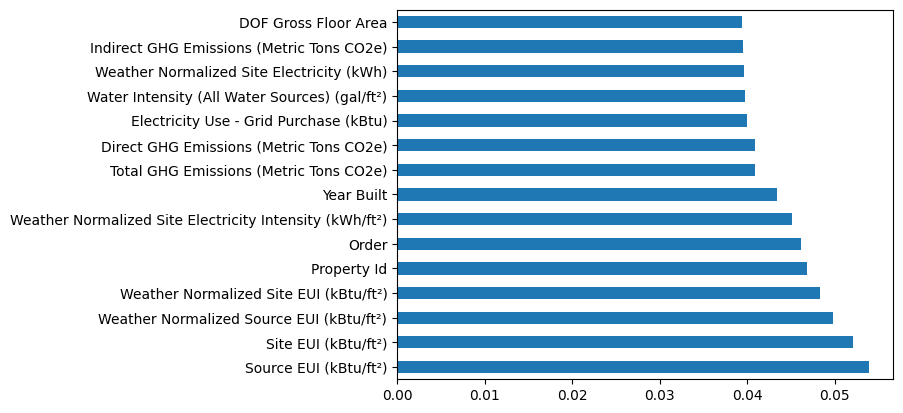

In [ ]:
tree_model = ExtraTreesClassifier(random_state=RANDOM_STATE)
tree_model.fit(x_num, y)

feat_importances = pd.Series(tree_model.feature_importances_, index=x_num.columns)
print(feat_importances.sort_values(ascending=False).head(15))

plt.figure(figsize=(10, 8))
feat_importances.nlargest(15).sort_values().plot(kind="barh")
plt.title("Feature importances (ExtraTreesClassifier)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14. Анализ мультиколлинеарности / Multicollinearity analysis

**RU.** Строим корреляционную матрицу числовых признаков. Сильно скоррелированные пары (EUI/площадь/выбросы в разных единицах) вредят линейной регрессии — часть из них удалим.

**EN.** Plot the correlation matrix of numeric features. Highly correlated pairs (EUI / gross-floor-area / emissions expressed in different units) hurt linear regression — we will remove some of them.

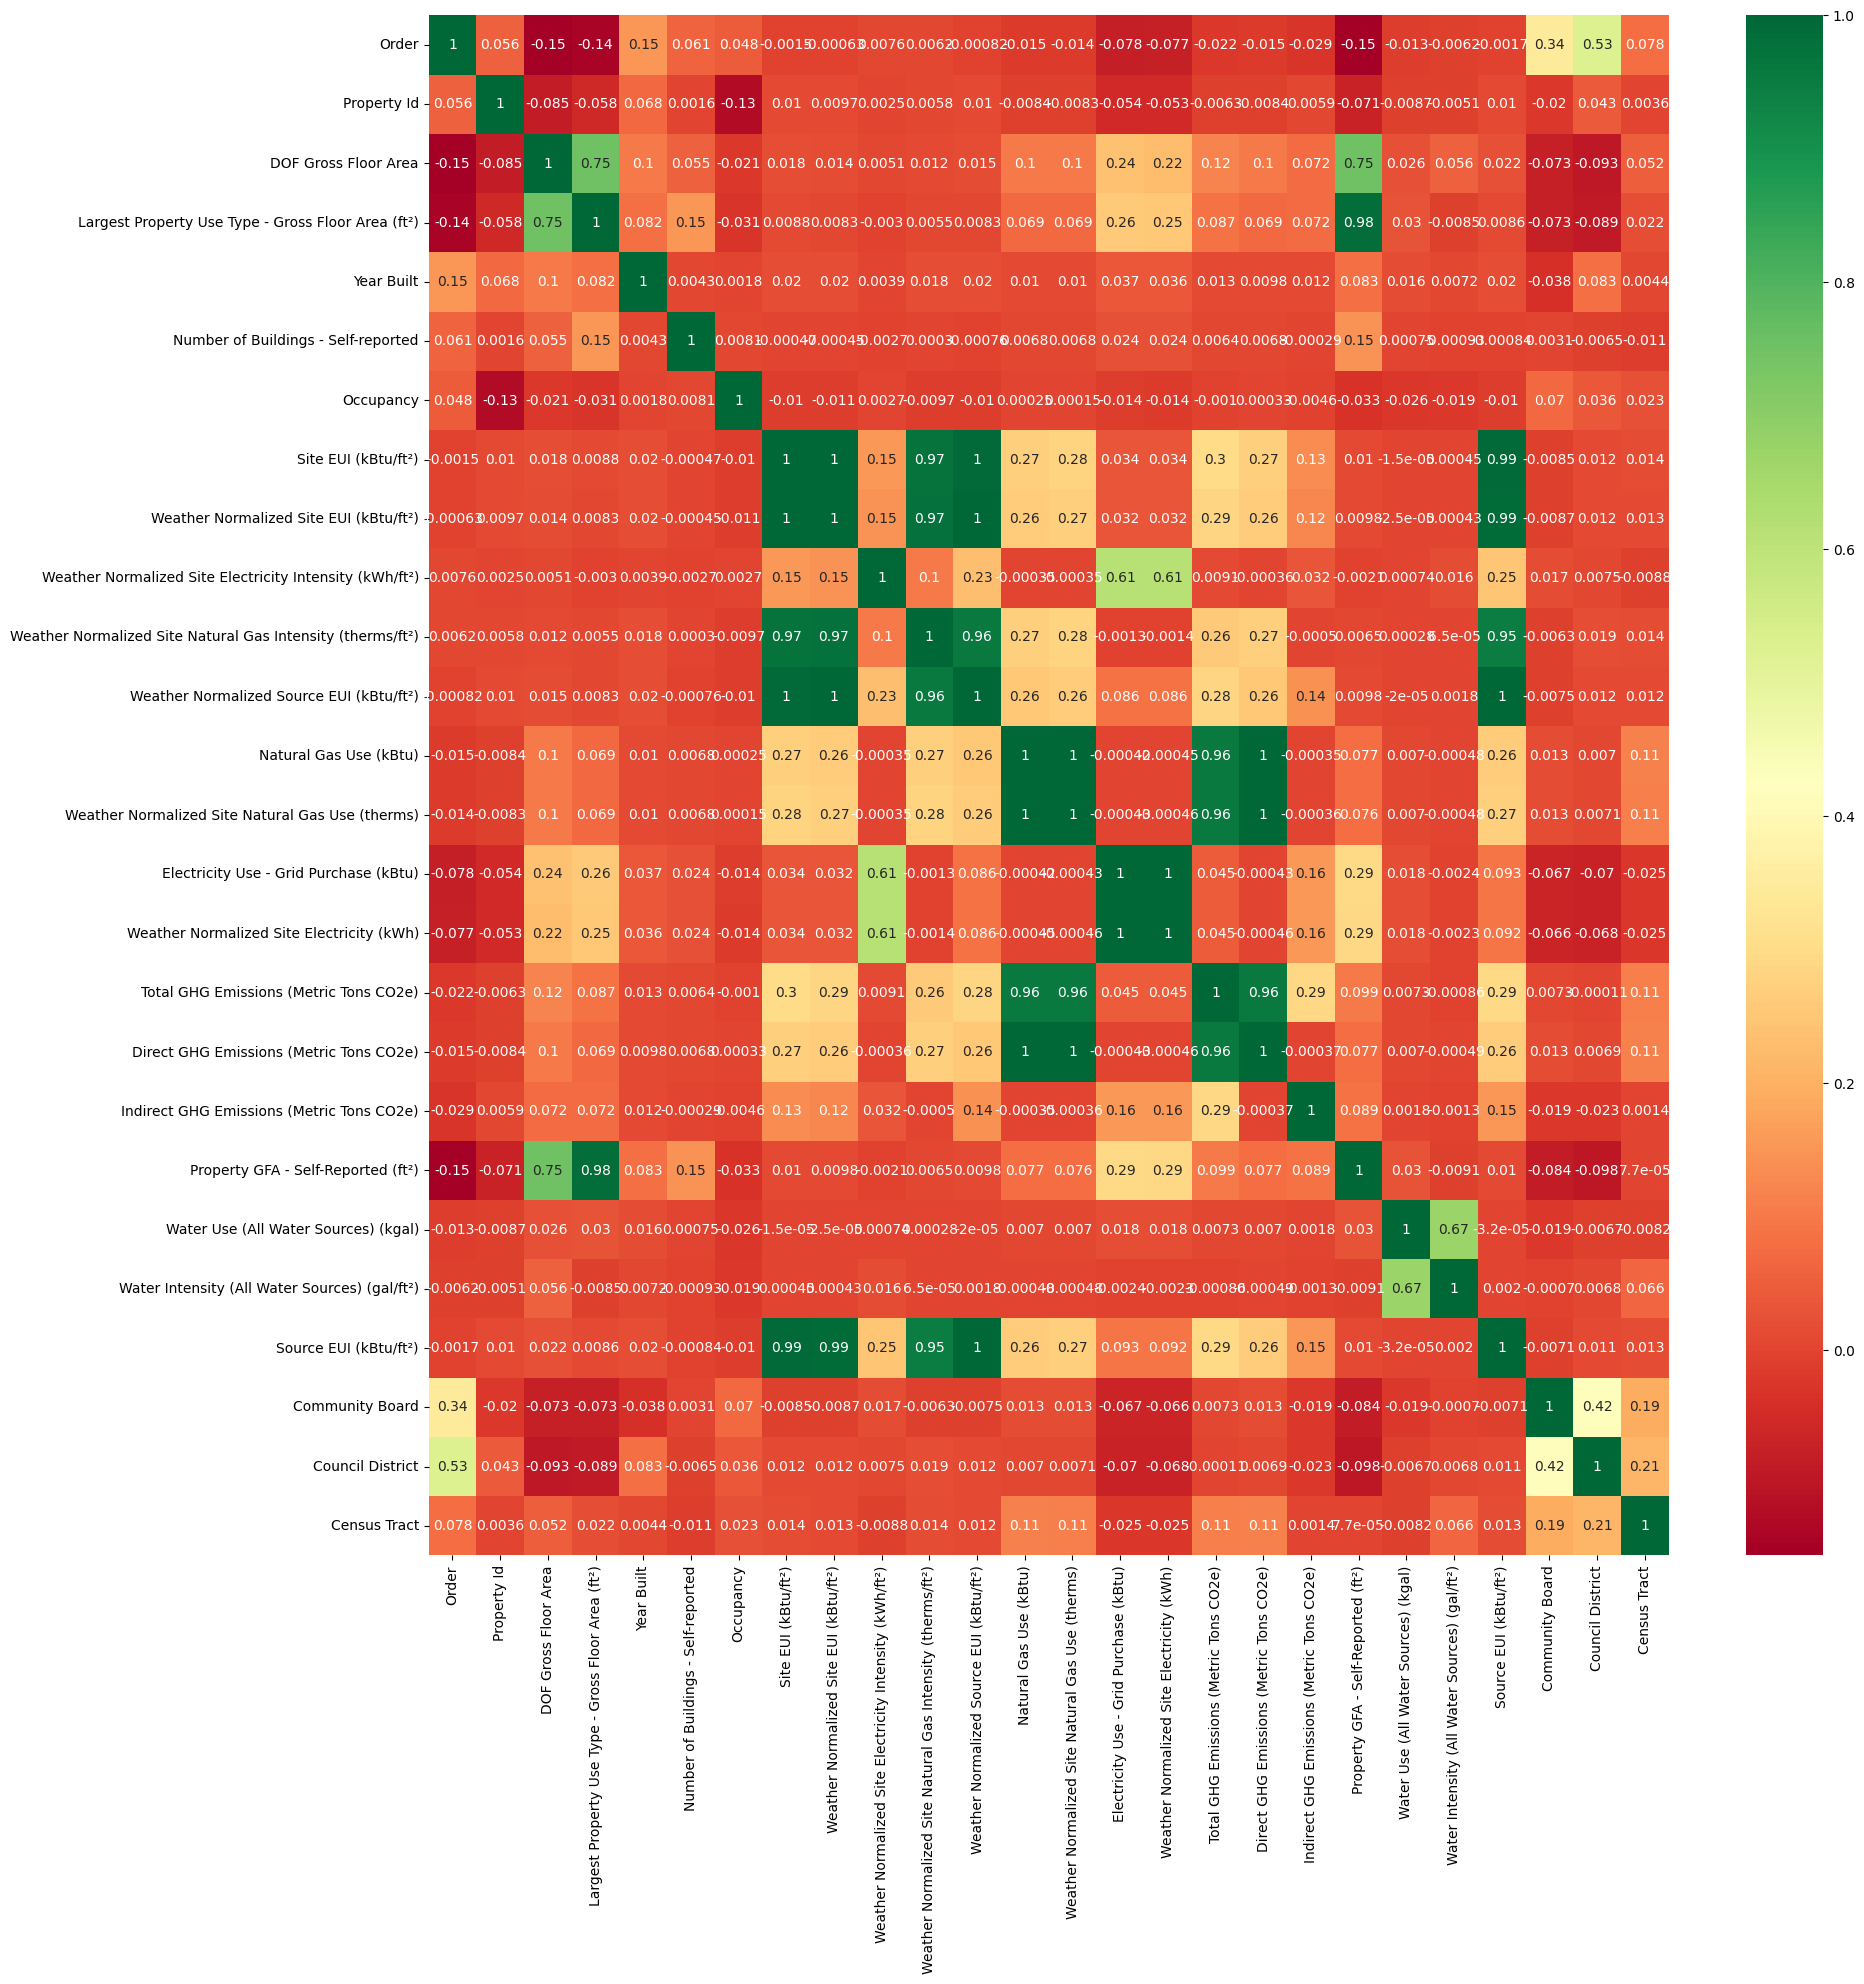

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(x_num.corr(), annot=True, cmap="RdYlGn")
plt.title("Correlation matrix — before dropping redundant features")
plt.show()

**RU.** Сброс дублирующих и явно нерелевантных признаков (порядковые номера, разные нормировки одних и тех же величин).

**EN.** Drop redundant and obviously irrelevant features (index numbers, different normalisations of the same quantities).

In [ ]:
REDUNDANT_NUMERIC = [
    "Order",
    "DOF Gross Floor Area",
    "Weather Normalized Site Electricity (kWh)",
    "Council District",
    "Census Tract",
    "Community Board",
    "Site EUI (kBtu/ft²)",
    "Weather Normalized Site EUI (kBtu/ft²)",
    "Source EUI (kBtu/ft²)",
    "Weather Normalized Site Electricity Intensity (kWh/ft²)",
    "Weather Normalized Site Natural Gas Intensity (therms/ft²)",
    "Weather Normalized Site Natural Gas Use (therms)",
    "Direct GHG Emissions (Metric Tons CO2e)",
    "Indirect GHG Emissions (Metric Tons CO2e)",
    "Property GFA - Self-Reported (ft²)",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Water Intensity (All Water Sources) (gal/ft²)",
    "Total GHG Emissions (Metric Tons CO2e)",
]

x_num = x_num.drop(columns=REDUNDANT_NUMERIC)

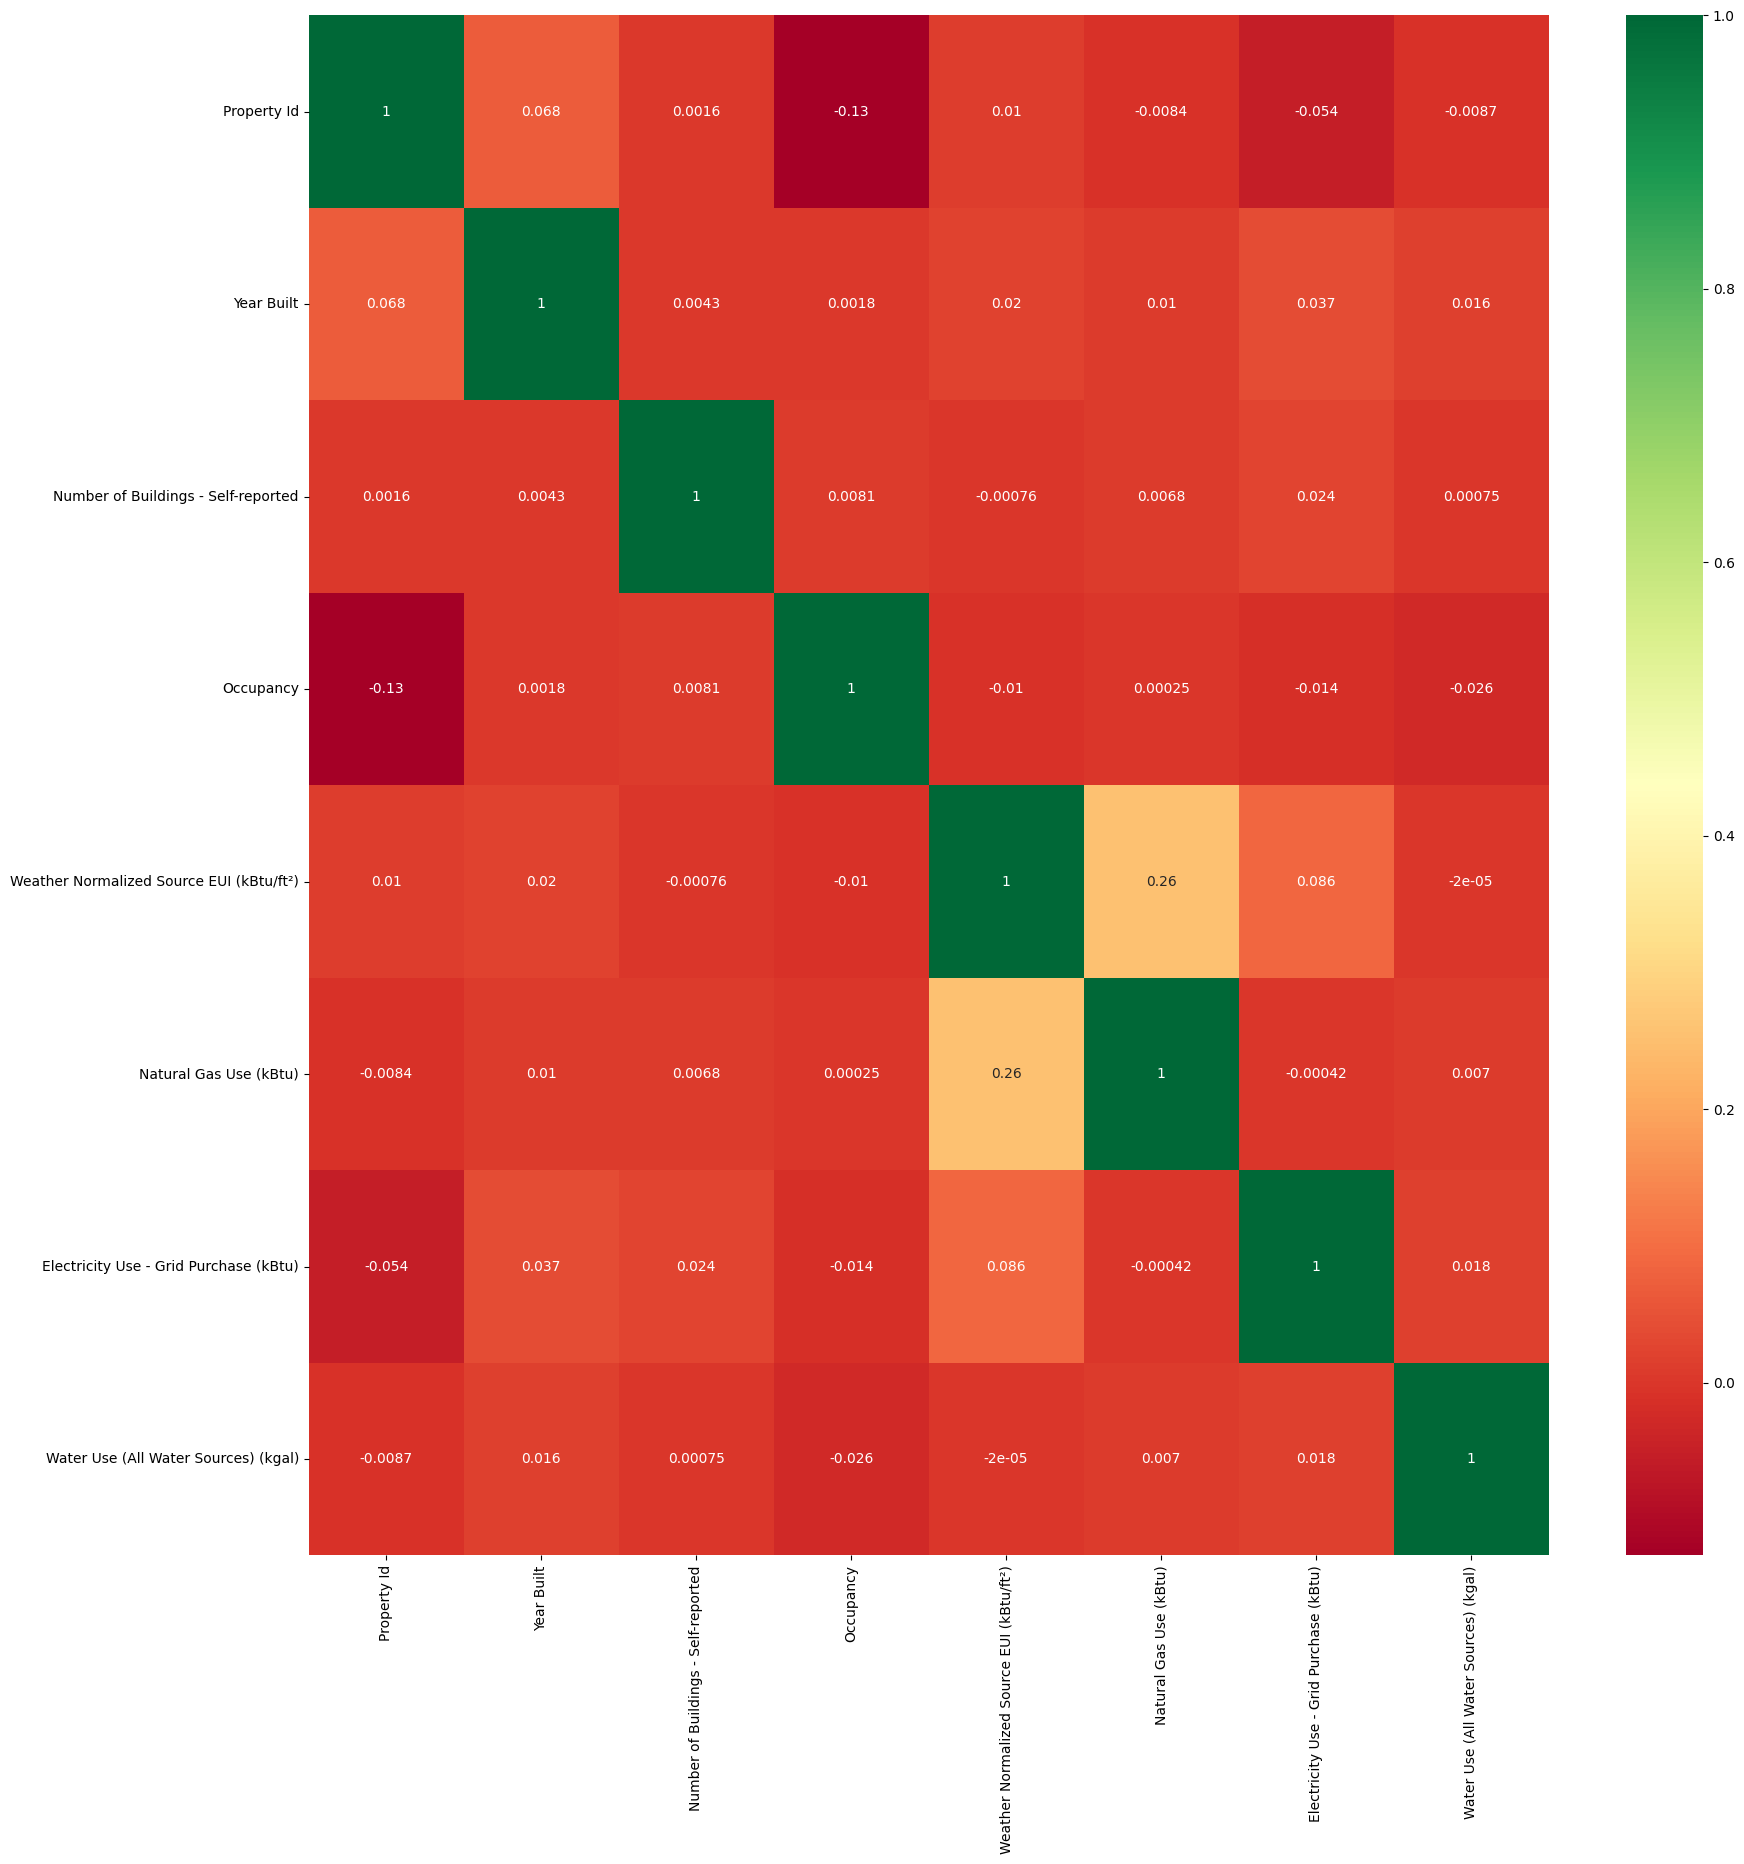

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(x_num.corr(), annot=True, cmap="RdYlGn")
plt.title("Correlation matrix — after dropping redundant features")
plt.show()

## 15. Объединение признаков / Concatenate features

**RU.** Перед объединением проверяем совпадение индексов. Любое расхождение означало бы, что где-то ранее строки были удалены несогласованно.

**EN.** Before merging we verify that the indices match. Any mismatch would indicate that rows were dropped inconsistently somewhere earlier.

In [ ]:
assert x_num.index.equals(x_cat.index), (
    "Индексы x_num и x_cat не совпадают / x_num and x_cat indices differ"
)
assert x_num.index.duplicated().sum() == 0 and x_cat.index.duplicated().sum() == 0, (
    "Найдены дубликаты индексов / duplicate indices found"
)

x_all = pd.concat([x_num, x_cat], axis=1)
print(f"Итоговая форма признаков / final feature matrix: {x_all.shape}")
print(f"Длина целевой переменной / target length: {len(y)}")

## 16. Разбиение и препроцессинг / Train–validation split & preprocessing

**RU.** Делим выборку на обучение и валидацию (70/30) и собираем общий `ColumnTransformer`: `StandardScaler` для числовых признаков и `OneHotEncoder(drop='first')` для категориальных. Один и тот же `preprocessor` переиспользуем для обеих моделей.

**EN.** Split the data 70/30 into training and validation sets and build a shared `ColumnTransformer`: `StandardScaler` for numeric columns and `OneHotEncoder(drop='first')` for categorical ones. The same `preprocessor` is reused by both models.

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    x_all, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

num_cols = x_train.select_dtypes(include=["number"]).columns
cat_cols = x_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            cat_cols,
        ),
    ]
)

print(f"x_train: {x_train.shape}  x_val: {x_val.shape}")

## 17. Вспомогательная функция для оценки / Evaluation helper

**RU.** Вместо того чтобы повторять `predict + метрики` для каждой модели, заводим одну функцию, которая делает предсказание и возвращает `MAE`, `RMSE`, `R²` в виде словаря.

**EN.** Instead of repeating `predict + metrics` for every model, we introduce a single helper that runs prediction and returns `MAE`, `RMSE`, and `R²` as a dict.

In [ ]:
def evaluate_regressor(model, x_val, y_val, name: str = "model") -> dict:
    """Сделать предсказание и распечатать метрики регрессии.

    Predict on ``x_val`` with ``model`` and print regression metrics
    (MAE, RMSE, R²). The metrics are also returned as a dict so the
    caller can compare models programmatically.
    """
    y_pred = model.predict(x_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    r2 = r2_score(y_val, y_pred)

    print(f"[{name}]  MAE: {mae:.2f}   RMSE: {rmse:.2f}   R²: {r2:.3f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

## 18. Модель LinearRegression / LinearRegression model

**RU.** Флаг `positive=True` заставляет коэффициенты быть неотрицательными — это соответствует физическому смыслу задачи (больше потребление и выбросы — ниже балл).

**EN.** The `positive=True` flag forces the coefficients to be non-negative, which matches the physical intuition of the problem (higher consumption and emissions → lower score).

In [ ]:
linreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression(copy_X=True, fit_intercept=True, positive=True)),
])

linreg_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Property Id', 'Year Built', 'Number of Buildings - Self-reported',
       'Occupancy', 'Weather Normalized Source EUI (kBtu/ft²)',
       'Natural Gas Use (kBtu)', 'Electricity Use - Grid Purchase (kBtu)',
       'Water Use (All Water Sources) (kgal)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Borough', 'Primary Property Type - Self Selected',
       'Largest Property Use Type', 'Metered Areas (Energy)',
       'Metered Areas  (Water)', 'Water Required?', 'NTA'],
      dtype='object'))])),
                ('regressor', LinearRegression(positive=True))])

In [ ]:
linreg_metrics = evaluate_regressor(linreg_model, x_val, y_val, name="LinearRegression")

## 19. Модель LinearSVR / LinearSVR model

**RU.** Второй бейзлайн — линейная SVM-регрессия (`LinearSVR`). Используем те же `preprocessor` и разбиение, что и для линейной регрессии, чтобы сравнение было честным.

**EN.** A second baseline — linear SVM regression (`LinearSVR`). We reuse the same `preprocessor` and data split as for linear regression to keep the comparison fair.

In [ ]:
svr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearSVR(
        C=1.0,
        epsilon=1.0,
        random_state=RANDOM_STATE,
        max_iter=10_000,
    )),
])

svr_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Property Id', 'Year Built', 'Number of Buildings - Self-reported',
       'Occupancy', 'Weather Normalized Source EUI (kBtu/ft²)',
       'Natural Gas Use (kBtu)', 'Electricity Use - Grid Purchase (kBtu)',
       'Water Use (All Water Sources) (kgal)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Borough', 'Primary Property Type - Self Selected',
       'Largest Property Use Type', 'Metered Areas (Energy)',
       'Metered Areas  (Water)', 'Water Required?', 'NTA'],
      dtype='object'))])),
                ('regressor',
                 LinearSVR(epsilon=1.0, max_iter=10000, random_state=42))])

In [ ]:
svr_metrics = evaluate_regressor(svr_model, x_val, y_val, name="LinearSVR")

## 20. Сравнение моделей / Model comparison

In [ ]:
pd.DataFrame([linreg_metrics, svr_metrics]).set_index("model").round(3)

## 21. Выводы / Conclusions

**RU.**

- Очистка данных оказалась самой ёмкой частью работы: удалено 13 идентификационных категориальных колонок, 18 избыточных или мультиколлинеарных числовых, все колонки с долей пропусков > 50%.
- По результатам `SelectKBest` (`chi²`) и важности признаков из `ExtraTreesClassifier` в топ-5 наиболее влиятельных признаков для `ENERGY STAR Score` стабильно входят:
  1. `Site EUI (kBtu/ft²)` — исходный показатель энергопотребления на      единицу площади;
  2. `Source EUI (kBtu/ft²)` — то же в пересчёте на первичную энергию;
  3. `Weather Normalized Site EUI (kBtu/ft²)` — тот же EUI,      нормированный на погоду;
  4. `Natural Gas Use (kBtu)` / `Electricity Use - Grid Purchase (kBtu)`      — абсолютное потребление газа и электричества;
  5. `Total GHG Emissions (Metric Tons CO2e)` — совокупные выбросы.
- `LinearRegression` с ограничением `positive=True` даёт более устойчивое предсказание, чем `LinearSVR` на стандартных гиперпараметрах — см. таблицу выше.

**EN.**

- Data cleaning turned out to be the heaviest part of the project: 13 identifier-like categorical columns, 18 redundant or multicollinear numeric ones, and every column with more than 50% missing values were dropped.
- Both `SelectKBest` (`chi²`) and `ExtraTreesClassifier` feature importances agree on the same top-5 drivers of the `ENERGY STAR Score`:
  1. `Site EUI (kBtu/ft²)` — raw energy use intensity per square foot;
  2. `Source EUI (kBtu/ft²)` — the same metric expressed in      source-energy terms;
  3. `Weather Normalized Site EUI (kBtu/ft²)` — weather-normalised EUI;
  4. `Natural Gas Use (kBtu)` / `Electricity Use - Grid Purchase (kBtu)`      — absolute gas and grid-electricity consumption;
  5. `Total GHG Emissions (Metric Tons CO2e)` — total greenhouse-gas      emissions.
- `LinearRegression` with `positive=True` produces a more stable fit than an out-of-the-box `LinearSVR` — see the metrics table above.